In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the dataset
data = pd.read_csv('Global_Pollution_Analysis.csv')

# Display first few rows
print(data.head())


        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste_in_tons  Energy_Recovered (in GWh)  \
0                 51.95                  94802.83                     158.14   
1                117.22                  56283.92                     498.04   
2                121.72                  56256.02                     489.51   
3                 93.58                  74864.73                     145.18   
4                121.55                  76862.06                      40.38   

   CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                   5.30                 41.11   
1   

In [32]:

# Phase 1: Data Preprocessing and Feature Engineering
# Handle missing values:
# For numerical features, fill missing values with the median
numerical_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
                  'Industrial_Waste_in_tons', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 
                  'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 
                  'Population (in millions)', 'GDP_Per_Capita (in USD)']

data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())

# For categorical features, fill missing values with the mode (most frequent value)
categorical_cols = ['Country', 'Year']
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])

# Encode categorical features using Label Encoding
encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

# Normalize numerical features using StandardScaler
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# Feature Engineering - Create energy consumption per capita (already available in the dataset but could be derived)
# Here we use the existing features, but more complex calculations can be added if needed


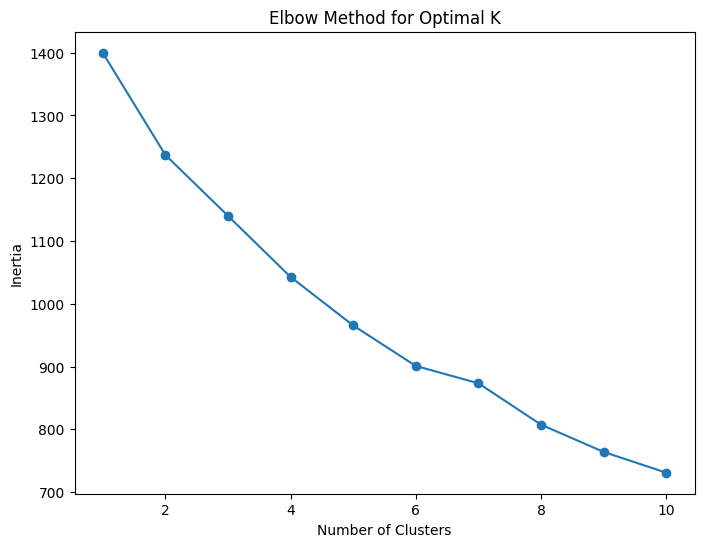

In [33]:

# Phase 2: Clustering using K-Means and Hierarchical Clustering

# Define input features for clustering (pollution data and energy metrics)
X = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
          'Industrial_Waste_in_tons', 'Energy_Consumption_Per_Capita (in MWh)', 
          'Plastic_Waste_Produced (in tons)', 'CO2_Emissions (in MT)']]

# K-Means Clustering
# Finding the optimal number of clusters using the Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


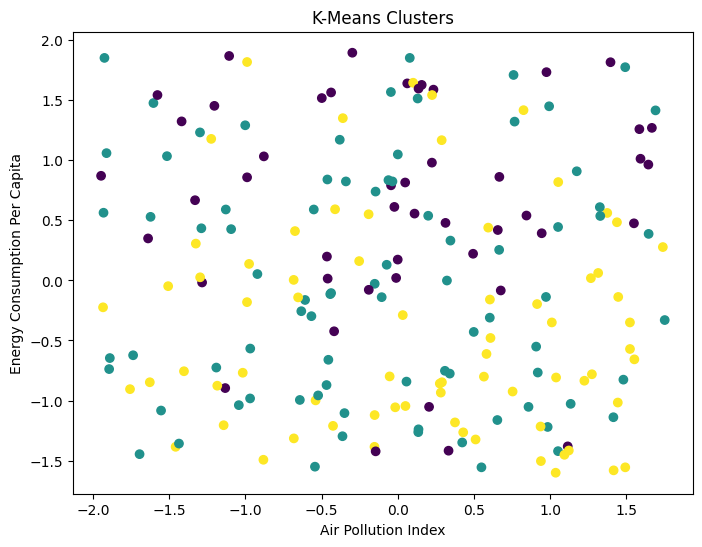

In [34]:

# Assuming optimal clusters are 3 based on the Elbow Method
kmeans = KMeans(n_clusters=3, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(X)

# Visualizing Clusters (2D scatter plot)
plt.figure(figsize=(8, 6))
plt.scatter(data['Air_Pollution_Index'], data['Energy_Consumption_Per_Capita (in MWh)'], c=data['KMeans_Cluster'], cmap='viridis')
plt.title('K-Means Clusters')
plt.xlabel('Air Pollution Index')
plt.ylabel('Energy Consumption Per Capita')
plt.show()


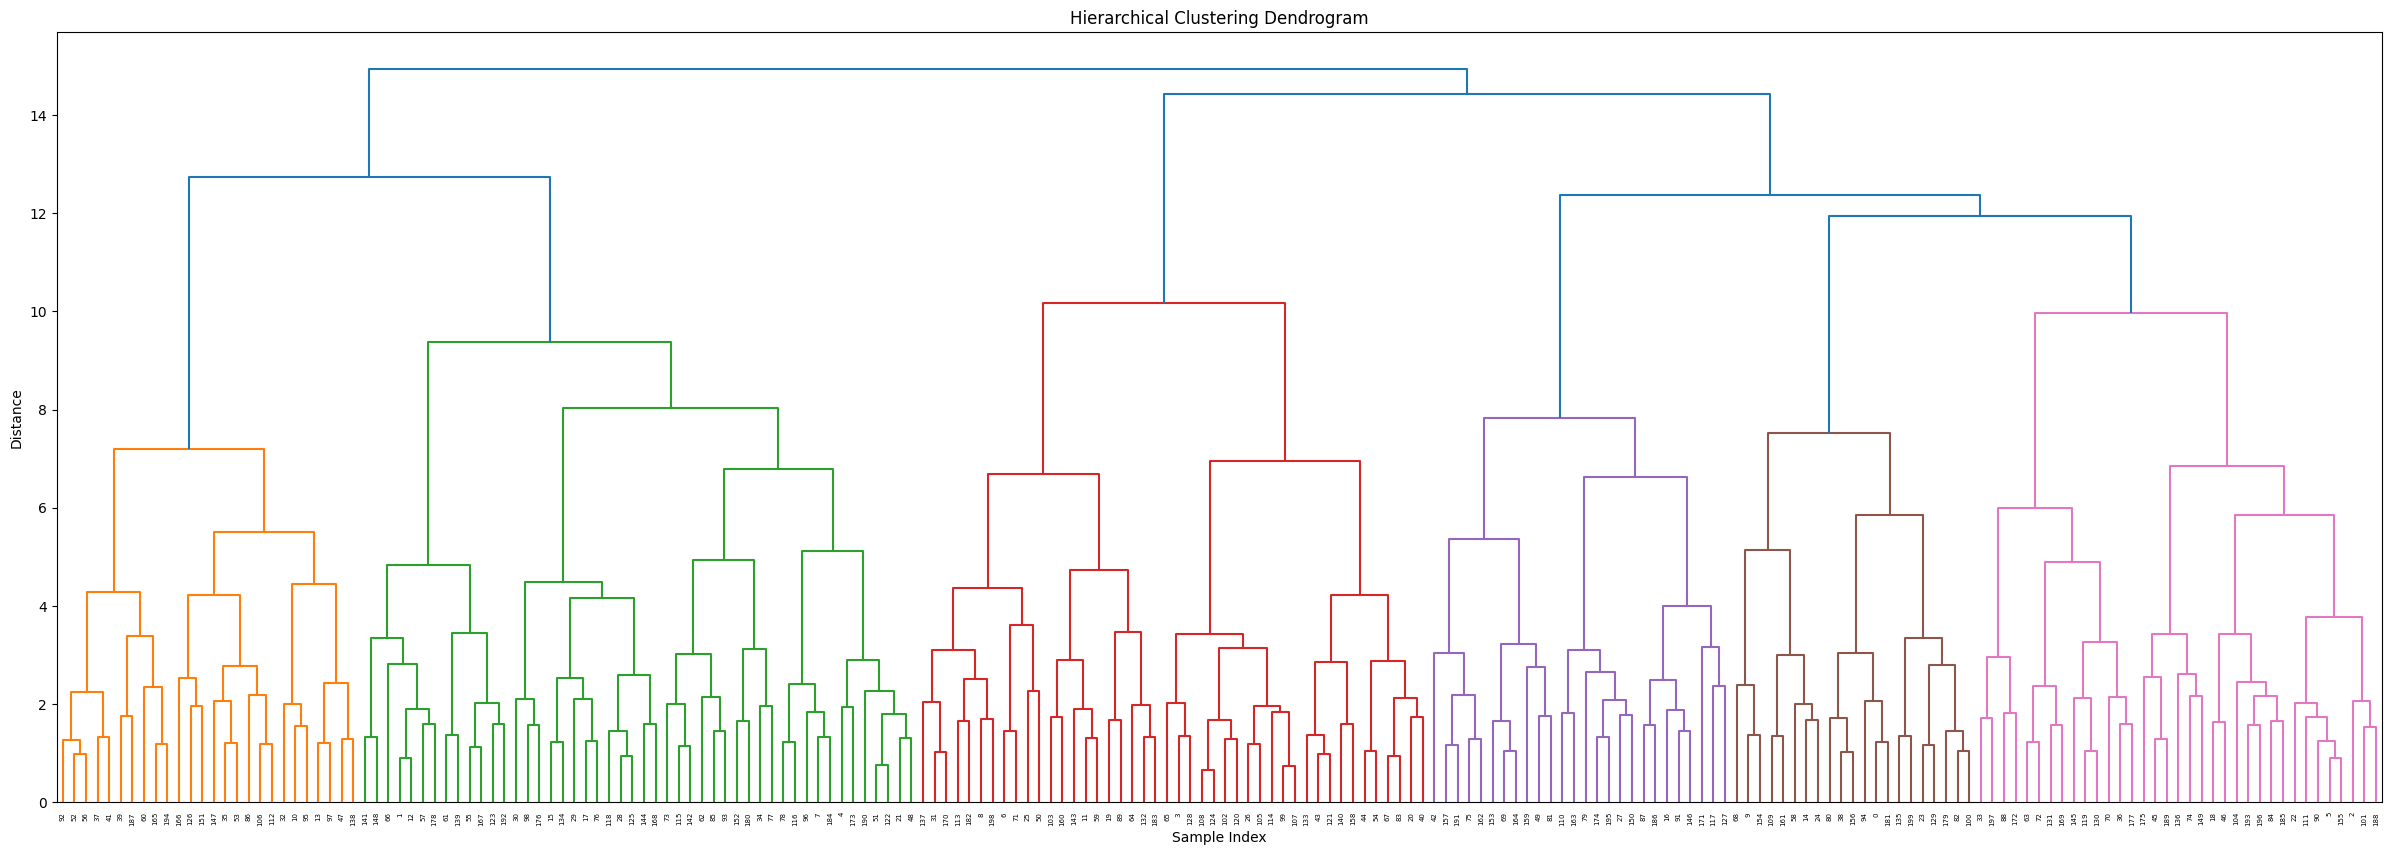

In [35]:

# Hierarchical Clustering (Agglomerative)
agg_clust = AgglomerativeClustering(n_clusters=3)
data['Agg_Cluster'] = agg_clust.fit_predict(X)

# Dendrogram
Z = linkage(X, method='ward')

plt.figure(figsize=(30, 10))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


In [36]:

# Phase 3: Neural Network for Energy Recovery Prediction

# Define input features for neural network (pollution and energy data)
X_nn = data[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
             'Industrial_Waste_in_tons', 'CO2_Emissions (in MT)', 'Plastic_Waste_Produced (in tons)']]
y_nn = data['Energy_Recovered (in GWh)']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Initialize and train the neural network
nn_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_nn = nn_model.predict(X_test)

# Performance metrics
print("Neural Network Performance Metrics:")
print("R^2:", r2_score(y_test, y_pred_nn))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred_nn))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred_nn))


Neural Network Performance Metrics:
R^2: -0.815889569894592
Mean Squared Error (MSE): 2.038402598144761
Mean Absolute Error (MAE): 1.136326087034631


In [37]:

# Phase 4: Reporting and Insights

# K-Means Cluster Analysis
print("K-Means Cluster Centers (Normalized):")
print(kmeans.cluster_centers_)

# Summary of Cluster Characteristics
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i+1} center:")
    print(f"  Feature 1 (Air Pollution): {center[0]}")
    print(f"  Feature 2 (Water Pollution): {center[1]}")
    print(f"  Feature 3 (Soil Pollution): {center[2]}")
    print(f"  Feature 4 (Industrial Waste): {center[3]}")
    print(f"  Feature 5 (Energy Consumption): {center[4]}")
    print(f"  Feature 6 (Plastic Waste): {center[5]}")
    print(f"  Feature 7 (CO2 Emissions): {center[6]}")
    print("-" * 30)

# Compare K-Means with Neural Network Performance
print("Neural Network R^2:", r2_score(y_test, y_pred_nn))
print("Neural Network MSE:", mean_squared_error(y_test, y_pred_nn))
print("Neural Network MAE:", mean_absolute_error(y_test, y_pred_nn))

# Actionable Insights:
# 1. Which pollution index has the most impact on energy recovery?
# 2. How can countries reduce pollution and increase energy recovery?
# 3. How can clustering be used to identify countries with similar environmental challenges?

# Final Deliverables:
# Jupyter Notebook (.ipynb) with the complete code for data preprocessing, clustering, and neural network modeling.
# Data Visualizations:
# Elbow Method graphs, dendrograms, neural network performance metrics.
# A comprehensive report summarizing the methodology, model evaluations, key findings, and actionable recommendations.



K-Means Cluster Centers (Normalized):
[[ 0.00341013 -0.37772842  0.5974072   0.67284505  0.64341778  0.07304581
   0.63107416]
 [-0.13185704 -0.16965995 -0.12171633 -0.96811786 -0.02118469 -0.2632227
   0.09607273]
 [ 0.15002818  0.44599087 -0.25489295  0.67270349 -0.40145762  0.25564941
  -0.52871055]]
Cluster 1 center:
  Feature 1 (Air Pollution): 0.003410133216621637
  Feature 2 (Water Pollution): -0.3777284224862197
  Feature 3 (Soil Pollution): 0.5974072037886364
  Feature 4 (Industrial Waste): 0.6728450465080033
  Feature 5 (Energy Consumption): 0.643417780317143
  Feature 6 (Plastic Waste): 0.07304581359861842
  Feature 7 (CO2 Emissions): 0.6310741579484394
------------------------------
Cluster 2 center:
  Feature 1 (Air Pollution): -0.13185703743024269
  Feature 2 (Water Pollution): -0.1696599510375904
  Feature 3 (Soil Pollution): -0.12171632947149418
  Feature 4 (Industrial Waste): -0.9681178625327198
  Feature 5 (Energy Consumption): -0.02118468919871633
  Feature 6 (Plasti